In [1]:
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv("glass.csv")

In [6]:
df.sample(5)

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
83,1.51594,13.09,3.52,1.55,72.87,0.68,8.05,0.00,0.09,2
11,1.51763,12.80,3.66,1.27,73.01,0.60,8.56,0.00,0.00,1
138,1.51674,12.79,3.52,1.54,73.36,0.66,7.90,0.00,0.00,2
206,1.51645,14.94,0.00,1.87,73.11,0.00,8.67,1.38,0.00,7
115,1.51846,13.41,3.89,1.33,72.38,0.51,8.28,0.00,0.00,2


In [8]:
from sklearn.neighbors import KNeighborsClassifier

In [10]:
from sklearn.model_selection import train_test_split

In [14]:
X = df.iloc[:,0:9]
y = df.iloc[:,-1]

In [15]:
X

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.00,0.0
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.00,0.0
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.00,0.0
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.00,0.0
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.00,0.0
...,...,...,...,...,...,...,...,...,...
209,1.51623,14.14,0.00,2.88,72.61,0.08,9.18,1.06,0.0
210,1.51685,14.92,0.00,1.99,73.06,0.00,8.40,1.59,0.0
211,1.52065,14.36,0.00,2.02,73.42,0.00,8.44,1.64,0.0
212,1.51651,14.38,0.00,1.94,73.61,0.00,8.48,1.57,0.0


In [16]:
y

0      1
1      1
2      1
3      1
4      1
      ..
209    7
210    7
211    7
212    7
213    7
Name: Type, Length: 214, dtype: int64

In [17]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [23]:
from sklearn.metrics import accuracy_score
scores = []

for i in range(1,31):
    
    knn = KNeighborsClassifier(n_neighbors=i)
    
    knn.fit(X_train,y_train)
    
    y_pred = knn.predict(X_test)

    scores.append(accuracy_score(y_test, y_pred))

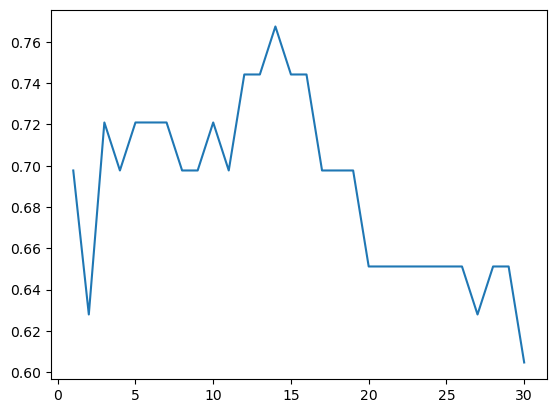

In [24]:
import matplotlib.pyplot as plt

plt.plot(range(1,31),scores)

In [28]:
knn = KNeighborsClassifier(n_neighbors=14)
knn.fit(X_train,y_train)
y_pred = knn.predict(X_test)
print(accuracy_score(y_test, y_pred))

0.7674418604651163


In [29]:
knn.predict(X_test[0])

ValueError: Expected 2D array, got 1D array instead:
array=[-0.29901568 -0.74564949  0.62064503 -0.1862544   0.51753219  0.19806241
 -0.29040715 -0.35407712 -0.573292  ].
Reshape your data either using array.reshape(-1, 1) if your data has a single feature or array.reshape(1, -1) if it contains a single sample.